In [ ]:
# 安装docker  compose
apt install docker-compose-plugin

# 编写compose.yaml 文件，文件放在11_k8s目录中，即可
# 代码如下：
services:
  tf-serving:
    image: docker.m.daocloud.io/tensorflow/serving:2.13.1
    # restart: "no"  
    ports:
      - "8500:8500" 
      - "8501:8501"
    volumes:
      - ./clothing_model:/models/clothing_model/1
    environment:
      - MODEL_NAME=clothing_model

  gateway:
    image: clothing_gateway:latest
    # restart: "no"
    ports:
      - "9696:9696"
    environment:
      - TF_SERVING_HOST=tf-serving:8500
    depends_on:
      - tf-serving

# 启动
docker compose up -d
docker  ps -a  #检查容器启动情况
# 测试1：在终端中跑
python   test_gate.way
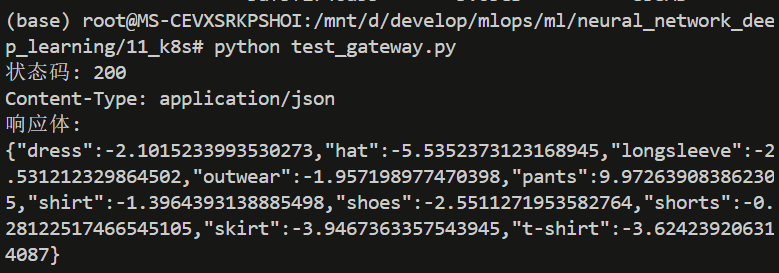
# 测试2：测试curl
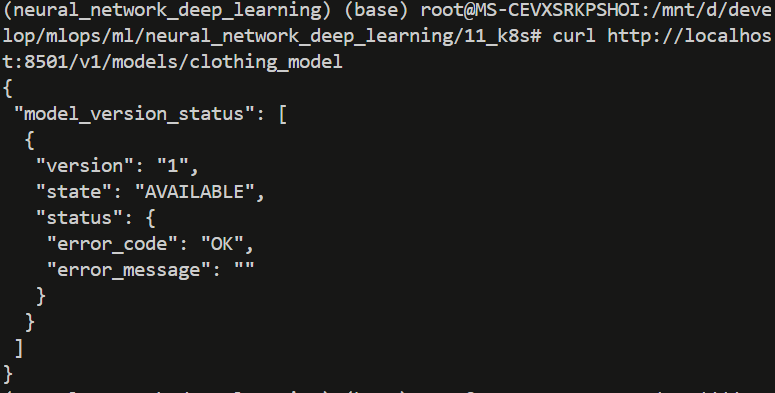